# Cross-Model Layer-Wise Probe Ablation — Corrected Comparison

This notebook consolidates the **executed three-seed results** from the Qwen3-8B, Mistral-7B-Instruct-v0.2, and Llama-3-8B-Instruct layer-wise probe notebooks.

- **Data used in the original runs:** 4,000 RAGTruth rows with stratified train/validation splits.
- **Depths:** early (`N/4`), mid (`N/2`), and late (`3N/4`).
- **Configurations:** three singles, three doubles, and one triple.
- **Reported values:** mean ± standard deviation over three seeds.
- **Scope:** CPU-only result synthesis; this notebook does not reload the LLMs or retrain probes.

All tables, rankings, and figures below are generated from one corrected dataframe. The two redundant figures from the earlier version have been removed.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display, Image
from matplotlib.lines import Line2D

OUTPUT_DIR = Path("compare_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_ORDER = ["Qwen3-8B", "Mistral-7B", "Llama-3-8B-Instruct"]
CONFIG_ORDER = ["early", "mid", "late", "early+mid", "early+late", "mid+late", "triple"]
KIND = {
    "early": "single", "mid": "single", "late": "single",
    "early+mid": "double", "early+late": "double", "mid+late": "double",
    "triple": "triple",
}
LAYER_LABEL = {
    "Qwen3-8B": {
        "early": "L9", "mid": "L18", "late": "L27",
        "early+mid": "L9+L18", "early+late": "L9+L27",
        "mid+late": "L18+L27", "triple": "L9+L18+L27",
    },
    "Mistral-7B": {
        "early": "L8", "mid": "L16", "late": "L24",
        "early+mid": "L8+L16", "early+late": "L8+L24",
        "mid+late": "L16+L24", "triple": "L8+L16+L24",
    },
    "Llama-3-8B-Instruct": {
        "early": "L8", "mid": "L16", "late": "L24",
        "early+mid": "L8+L16", "early+late": "L8+L24",
        "mid+late": "L16+L24", "triple": "L8+L16+L24",
    },
}
PARAMS = {
    "Qwen3-8B": {"single": 4_262_660, "double": 8_456_964, "triple": 12_651_268},
    "Mistral-7B": {"single": 4_786_948, "double": 9_505_540, "triple": 14_224_132},
    "Llama-3-8B-Instruct": {"single": 4_786_948, "double": 9_505_540, "triple": 14_224_132},
}

# Exact mean/std values copied from the executed summary tables in the three source notebooks.
# model -> config -> (AUROC mean, AUROC std, Accuracy mean, Accuracy std, F1 mean, F1 std)
RESULTS = {
    "Qwen3-8B": {
        "early":      (0.8103, 0.0131, 0.7329, 0.0222, 0.6915, 0.0225),
        "mid":        (0.8466, 0.0227, 0.7650, 0.0238, 0.7380, 0.0185),
        "late":       (0.8417, 0.0152, 0.7671, 0.0244, 0.7234, 0.0386),
        "early+mid":  (0.8417, 0.0236, 0.7612, 0.0266, 0.7246, 0.0217),
        "early+late": (0.8364, 0.0159, 0.7562, 0.0154, 0.7226, 0.0225),
        "mid+late":   (0.8515, 0.0149, 0.7642, 0.0168, 0.7395, 0.0248),
        "triple":     (0.8427, 0.0186, 0.7621, 0.0069, 0.7289, 0.0113),
    },
    "Mistral-7B": {
        "early":      (0.7998, 0.0078, 0.7288, 0.0022, 0.6879, 0.0155),
        "mid":        (0.8233, 0.0050, 0.7388, 0.0070, 0.7118, 0.0073),
        "late":       (0.8047, 0.0071, 0.7292, 0.0026, 0.6897, 0.0113),
        "early+mid":  (0.8210, 0.0078, 0.7438, 0.0033, 0.6999, 0.0109),
        "early+late": (0.8047, 0.0106, 0.7283, 0.0126, 0.6812, 0.0241),
        "mid+late":   (0.8150, 0.0048, 0.7367, 0.0051, 0.6956, 0.0031),
        "triple":     (0.8179, 0.0037, 0.7354, 0.0080, 0.6965, 0.0069),
    },
    "Llama-3-8B-Instruct": {
        "early":      (0.8086, 0.0116, 0.7275, 0.0132, 0.6868, 0.0192),
        "mid":        (0.8371, 0.0112, 0.7596, 0.0071, 0.7286, 0.0074),
        "late":       (0.8209, 0.0116, 0.7417, 0.0177, 0.7065, 0.0157),
        "early+mid":  (0.8284, 0.0162, 0.7429, 0.0113, 0.7027, 0.0106),
        "early+late": (0.8268, 0.0205, 0.7504, 0.0190, 0.7129, 0.0181),
        "mid+late":   (0.8356, 0.0141, 0.7542, 0.0140, 0.7172, 0.0129),
        "triple":     (0.8305, 0.0136, 0.7417, 0.0182, 0.7049, 0.0160),
    },
}

rows = []
for model in MODEL_ORDER:
    for config in CONFIG_ORDER:
        auroc, auroc_std, acc, acc_std, f1, f1_std = RESULTS[model][config]
        tier = KIND[config]
        rows.append({
            "model": model,
            "config": config,
            "layers": LAYER_LABEL[model][config],
            "tier": tier,
            "auroc": auroc,
            "auroc_std": auroc_std,
            "accuracy": acc,
            "accuracy_std": acc_std,
            "f1": f1,
            "f1_std": f1_std,
            "params": PARAMS[model][tier],
        })

df = pd.DataFrame(rows)
df["model"] = pd.Categorical(df["model"], categories=MODEL_ORDER, ordered=True)
df["config"] = pd.Categorical(df["config"], categories=CONFIG_ORDER, ordered=True)
df = df.sort_values(["model", "config"]).reset_index(drop=True)

# Sanity checks against the corrected source-notebook values.
assert np.isclose(df.query("model == 'Mistral-7B' and config == 'mid'")["auroc"].iloc[0], 0.8233)
assert np.isclose(df.query("model == 'Mistral-7B' and config == 'early'")["auroc"].iloc[0], 0.7998)
assert len(df) == 21 and df.isna().sum().sum() == 0

result_table = df.copy()
result_table["AUROC (mean ± std)"] = result_table.apply(
    lambda r: f"{r.auroc:.4f} ± {r.auroc_std:.4f}", axis=1
)
result_table["Accuracy (mean ± std)"] = result_table.apply(
    lambda r: f"{r.accuracy:.4f} ± {r.accuracy_std:.4f}", axis=1
)
result_table["F1 (mean ± std)"] = result_table.apply(
    lambda r: f"{r.f1:.4f} ± {r.f1_std:.4f}", axis=1
)
result_table["Probe parameters"] = result_table["params"].map(lambda x: f"{x:,}")
result_table = result_table[[
    "model", "config", "layers", "AUROC (mean ± std)",
    "Accuracy (mean ± std)", "F1 (mean ± std)", "Probe parameters"
]].rename(columns={"model": "Model", "config": "Configuration", "layers": "Layers"})

display(result_table)

# Save the corrected machine-readable table.
df.to_csv(OUTPUT_DIR / "corrected_cross_model_layerwise_results.csv", index=False)
print(f"Saved corrected result table: {OUTPUT_DIR / 'corrected_cross_model_layerwise_results.csv'}")

,Model,Configuration,Layers,AUROC (mean ± std),Accuracy (mean ± std),F1 (mean ± std),Probe parameters
0,Qwen3-8B,early,L9,0.8103 ± 0.0131,0.7329 ± 0.0222,0.6915 ± 0.0225,"4,262,660"
1,Qwen3-8B,mid,L18,0.8466 ± 0.0227,0.7650 ± 0.0238,0.7380 ± 0.0185,"4,262,660"
2,Qwen3-8B,late,L27,0.8417 ± 0.0152,0.7671 ± 0.0244,0.7234 ± 0.0386,"4,262,660"
3,Qwen3-8B,early+mid,L9+L18,0.8417 ± 0.0236,0.7612 ± 0.0266,0.7246 ± 0.0217,"8,456,964"
4,Qwen3-8B,early+late,L9+L27,0.8364 ± 0.0159,0.7562 ± 0.0154,0.7226 ± 0.0225,"8,456,964"
5,Qwen3-8B,mid+late,L18+L27,0.8515 ± 0.0149,0.7642 ± 0.0168,0.7395 ± 0.0248,"8,456,964"
6,Qwen3-8B,triple,L9+L18+L27,0.8427 ± 0.0186,0.7621 ± 0.0069,0.7289 ± 0.0113,"12,651,268"
7,Mistral-7B,early,L8,0.7998 ± 0.0078,0.7288 ± 0.0022,0.6879 ± 0.0155,"4,786,948"
8,Mistral-7B,mid,L16,0.8233 ± 0.0050,0.7388 ± 0.0070,0.7118 ± 0.0073,"4,786,948"
9,Mistral-7B,late,L24,0.8047 ± 0.0071,0.7292 ± 0.0026,0.6897 ± 0.0113,"4,786,948"


Saved corrected result table: compare_output/corrected_cross_model_layerwise_results.csv


In [2]:
# Derive winners and the cross-model AUROC ranking directly from the corrected dataframe.
metric_rows = []
for model in MODEL_ORDER:
    model_df = df[df["model"] == model]
    row = {"Model": model}
    for metric, label in [("auroc", "Best AUROC"), ("accuracy", "Best accuracy"), ("f1", "Best F1")]:
        winner = model_df.loc[model_df[metric].idxmax()]
        row[label] = f"{winner['config']} ({winner[metric]:.4f})"
    metric_rows.append(row)

winner_table = pd.DataFrame(metric_rows)
display(winner_table)

auroc_pivot = (
    df.pivot(index="config", columns="model", values="auroc")
      .reindex(index=CONFIG_ORDER, columns=MODEL_ORDER)
)
rank_per_model = auroc_pivot.rank(axis=0, ascending=False, method="average")
rank_table = rank_per_model.copy()
rank_table["Average rank"] = rank_table.mean(axis=1)
rank_table = rank_table.sort_values("Average rank").round(2)
rank_table.index.name = "Configuration"
display(rank_table)

best_system_config = rank_table.index[0]
assert best_system_config == "mid"

triple_vs_mid = []
for model in MODEL_ORDER:
    model_df = df[df["model"] == model].set_index("config")
    triple_vs_mid.append({
        "Model": model,
        "Triple − mid AUROC": model_df.loc["triple", "auroc"] - model_df.loc["mid", "auroc"],
        "Triple / mid parameters": model_df.loc["triple", "params"] / model_df.loc["mid", "params"],
    })
triple_vs_mid = pd.DataFrame(triple_vs_mid)
triple_vs_mid["Triple − mid AUROC"] = triple_vs_mid["Triple − mid AUROC"].map(lambda x: f"{x:+.4f}")
triple_vs_mid["Triple / mid parameters"] = triple_vs_mid["Triple / mid parameters"].map(lambda x: f"{x:.2f}×")
display(triple_vs_mid)

print(f"System-agnostic AUROC-rank winner: {best_system_config!r} "
      f"(average rank {rank_table.loc[best_system_config, 'Average rank']:.2f}).")

,Model,Best AUROC,Best accuracy,Best F1
0,Qwen3-8B,mid+late (0.8515),late (0.7671),mid+late (0.7395)
1,Mistral-7B,mid (0.8233),early+mid (0.7438),mid (0.7118)
2,Llama-3-8B-Instruct,mid (0.8371),mid (0.7596),mid (0.7286)


model,Qwen3-8B,Mistral-7B,Llama-3-8B-Instruct,Average rank
Configuration,,,,
mid,2.0,1.0,1.0,1.33
mid+late,1.0,4.0,2.0,2.33
triple,3.0,3.0,3.0,3.00
early+mid,4.5,2.0,4.0,3.50
late,4.5,5.5,6.0,5.33
early+late,6.0,5.5,5.0,5.50
early,7.0,7.0,7.0,7.00


,Model,Triple − mid AUROC,Triple / mid parameters
0,Qwen3-8B,-0.0039,2.97×
1,Mistral-7B,-0.0054,2.97×
2,Llama-3-8B-Instruct,-0.0066,2.97×


System-agnostic AUROC-rank winner: 'mid' (average rank 1.33).


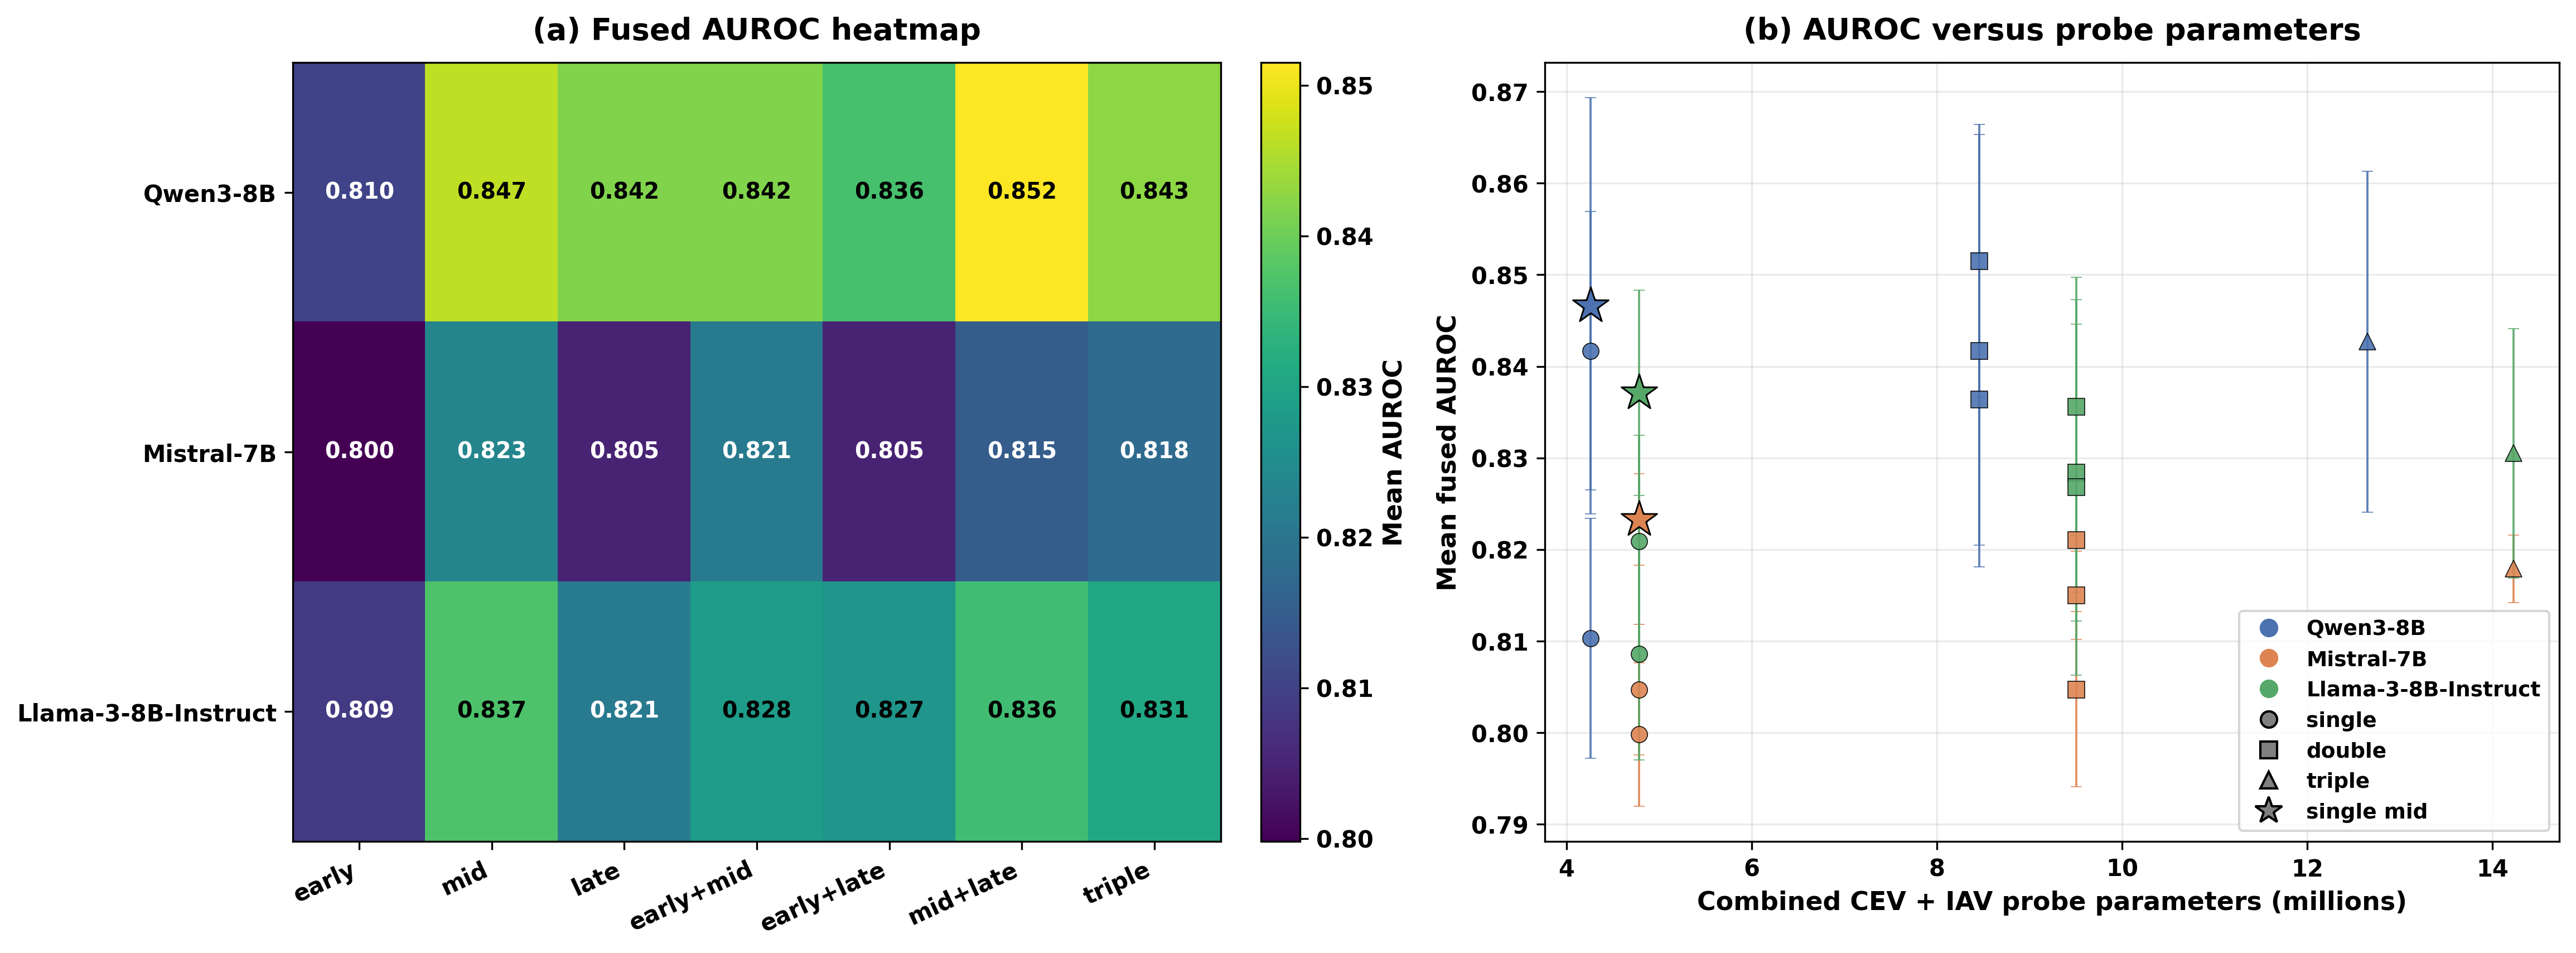

Saved bold 300-dpi figure: compare_output/layerwise_auroc_heatmap_and_params_scatter_bold.png


In [3]:
# Requested final figure only:
# (a) corrected AUROC heatmap; (b) AUROC-versus-parameter scatter with seed std error bars.
# All figure text is bold and enlarged for improved readability.
heat = auroc_pivot.T.reindex(index=MODEL_ORDER, columns=CONFIG_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.8))

TITLE_SIZE = 13
LABEL_SIZE = 11
TICK_SIZE = 10
ANNOTATION_SIZE = 9.5
LEGEND_SIZE = 9

# (a) Heatmap
im = axes[0].imshow(heat.to_numpy(), aspect="auto", cmap="viridis")
axes[0].set_xticks(np.arange(len(CONFIG_ORDER)))
axes[0].set_xticklabels(
    CONFIG_ORDER,
    rotation=25,
    ha="right",
    fontsize=TICK_SIZE,
    fontweight="bold",
)
axes[0].set_yticks(np.arange(len(MODEL_ORDER)))
axes[0].set_yticklabels(
    MODEL_ORDER,
    fontsize=TICK_SIZE,
    fontweight="bold",
)
axes[0].set_title(
    "(a) Fused AUROC heatmap",
    fontsize=TITLE_SIZE,
    fontweight="bold",
    pad=10,
)

vmin, vmax = float(heat.min().min()), float(heat.max().max())
threshold = (vmin + vmax) / 2
for r in range(heat.shape[0]):
    for c in range(heat.shape[1]):
        value = float(heat.iat[r, c])
        axes[0].text(
            c,
            r,
            f"{value:.3f}",
            ha="center",
            va="center",
            fontsize=ANNOTATION_SIZE,
            fontweight="bold",
            color="white" if value < threshold else "black",
        )

cbar = fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
cbar.set_label(
    "Mean AUROC",
    fontsize=LABEL_SIZE,
    fontweight="bold",
)
cbar.ax.tick_params(labelsize=TICK_SIZE)
for tick_label in cbar.ax.get_yticklabels():
    tick_label.set_fontweight("bold")

# (b) AUROC vs parameter count
model_colors = {
    "Qwen3-8B": "#4C72B0",
    "Mistral-7B": "#DD8452",
    "Llama-3-8B-Instruct": "#55A868",
}
markers = {"single": "o", "double": "s", "triple": "^"}

for model in MODEL_ORDER:
    model_df = df[df["model"] == model]
    for tier in ["single", "double", "triple"]:
        tier_df = model_df[model_df["tier"] == tier]
        axes[1].errorbar(
            tier_df["params"] / 1e6,
            tier_df["auroc"],
            yerr=tier_df["auroc_std"],
            fmt=markers[tier],
            linestyle="none",
            markersize=7,
            capsize=2.5,
            elinewidth=0.9,
            markeredgecolor="black",
            markeredgewidth=0.4,
            color=model_colors[model],
            alpha=0.90,
        )

    # Highlight the recommended single-mid point.
    mid_row = model_df[model_df["config"] == "mid"].iloc[0]
    axes[1].scatter(
        mid_row["params"] / 1e6,
        mid_row["auroc"],
        marker="*",
        s=260,
        color=model_colors[model],
        edgecolor="black",
        linewidth=0.7,
        zorder=5,
    )

kind_handles = [
    Line2D(
        [0],
        [0],
        marker=markers[tier],
        linestyle="none",
        color="gray",
        markeredgecolor="black",
        markersize=7,
        label=tier,
    )
    for tier in ["single", "double", "triple"]
]
model_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        color=model_colors[model],
        markersize=7,
        label=model,
    )
    for model in MODEL_ORDER
]
mid_handle = [
    Line2D(
        [0],
        [0],
        marker="*",
        linestyle="none",
        color="gray",
        markeredgecolor="black",
        markersize=12,
        label="single mid",
    )
]
legend = axes[1].legend(
    handles=model_handles + kind_handles + mid_handle,
    fontsize=LEGEND_SIZE,
    loc="lower right",
    frameon=True,
)
for legend_text in legend.get_texts():
    legend_text.set_fontweight("bold")

axes[1].set_xlabel(
    "Combined CEV + IAV probe parameters (millions)",
    fontsize=LABEL_SIZE,
    fontweight="bold",
)
axes[1].set_ylabel(
    "Mean fused AUROC",
    fontsize=LABEL_SIZE,
    fontweight="bold",
)
axes[1].set_title(
    "(b) AUROC versus probe parameters",
    fontsize=TITLE_SIZE,
    fontweight="bold",
    pad=10,
)
axes[1].tick_params(axis="both", labelsize=TICK_SIZE)
for tick_label in axes[1].get_xticklabels() + axes[1].get_yticklabels():
    tick_label.set_fontweight("bold")

axes[1].grid(alpha=0.25)
axes[1].set_axisbelow(True)

fig.tight_layout()

figure_path = OUTPUT_DIR / "layerwise_auroc_heatmap_and_params_scatter_bold.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.close(fig)
display(Image(filename=str(figure_path)))

print(f"Saved bold 300-dpi figure: {figure_path}")

## Corrected conclusion

- The **single mid layer** is the strongest system-agnostic choice by mean AUROC rank: **1.33** across the three backbones.
- Qwen’s highest mean AUROC comes from `mid+late` (**0.8515 ± 0.0149**), but its improvement over the single mid layer is only **0.0049** while nearly doubling probe parameters.
- Mistral’s corrected best AUROC and F1 both come from the single mid layer: **0.8233 ± 0.0050** AUROC and **0.7118 ± 0.0073** F1. `early+mid` has the highest accuracy (**0.7438 ± 0.0033**).
- Llama’s single mid layer wins AUROC, accuracy, and F1.
- The triple probe has lower mean AUROC than the single mid probe in all three models while using about **2.97×** as many probe parameters.

Only `layerwise_auroc_heatmap_and_params_scatter.png` is generated. The earlier grouped-bar and single-layer/best-tier figures, duplicated cells, and repeated result summaries have been removed.